In [43]:
import os
import json
import csv
import h5py

from collections import defaultdict
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
def lowest_tn(folder_path):
    lowest_energy = {}
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as file:
                data = json.load(file)
                instance = data['columns'][data['colindex']['lookup']['instance']-1][0].split('_P')[0]
                energy = data['columns'][data['colindex']['lookup']['energy']-1][0]
                if instance in lowest_energy:
                    if energy < lowest_energy[instance]:
                        lowest_energy[instance] = energy
                else:
                    lowest_energy[instance] = energy
    return lowest_energy

In [45]:
def all_energies_tn(folder_path):
    all_energies = {}
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)

                lookup = data["colindex"]["lookup"]
                
                instance_idx = lookup["instance"] - 1
                energy_idx = lookup["energy"] - 1

                instances = data['columns'][instance_idx]
                energies = data['columns'][energy_idx]

                for i in range(len(instances)):
                    instance = instances[i].split('_P')[0]
                    energy = float(energies[i])

                    if instance in all_energies:
                        all_energies[instance].append(energy)
                    else:
                        all_energies[instance] = [energy]
    
    return all_energies


In [46]:
def lowest_dwave(csv_file):
    lowest_energy = {}
    
    with open(csv_file, 'r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            instance = row['instance'].split('.txt')[0]
            energy = float(row['dwave_energy'])
            
            if instance in lowest_energy:
                if energy < lowest_energy[instance]:
                    lowest_energy[instance] = energy
            else:
                lowest_energy[instance] = energy
    
    return lowest_energy

In [47]:
def lowest_sbm(csv_file_sbm):
    lowest_energy = {}
    
    with open(csv_file_sbm, 'r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            instance = row['instance'].split('_P')[0]
            energy = float(row['sbm_energy'])
            
            if instance in lowest_energy:
                if energy < lowest_energy[instance]:
                    lowest_energy[instance] = energy
            else:
                lowest_energy[instance] = energy
    
    return lowest_energy

In [48]:
def lowest_energy_total(csv_file):
    lowest_energy = {}
    
    with open(csv_file, 'r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            instance = row['instance'].split('.txt')[0]
            energy = float(row['gnd_energy'])
    
            lowest_energy[instance] = energy
    
    return lowest_energy

In [49]:
def find_lowest_energy(instances_tn, instances_dw, instances_sbm):
    data_tn = lowest_tn(instances_tn)
    data_dw = lowest_dwave(instances_dw)
    data_sbm = lowest_sbm(instances_sbm)
    lowest_energy = lowest_energy_total(instances_dw) 
    
    return lowest_energy, data_tn, data_sbm, data_dw

In [50]:
def plot_instance_energy(instances_tn, instances_dw, instances_sbm):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm)
    sorted_lowest_energy = dict(sorted(lowest_energy.items()))
    sorted_data_tn = dict(sorted(data_tn.items()))
    sorted_data_sbm = dict(sorted(data_sbm.items()))
    sorted_data_dw = dict(sorted(data_dw.items()))

    all_instances = sorted(set(sorted_lowest_energy.keys()) | set(sorted_data_tn.keys()) | set(sorted_data_sbm.keys()) | set(sorted_data_dw.keys()))
    
    p2_groups = defaultdict(lambda: {'instances': [], 'energies_tn': []})
    
    for instance in all_instances:
        parts = instance.split('_')
        if 'p2' in parts:
            p2_index = parts.index('p2') + 1
            p2_value = float(parts[p2_index])
            inst_name = '_'.join(parts[-2:])  # inst_1, inst_2, etc.
            p2_groups[p2_value]['instances'].append(inst_name)
            p2_groups[p2_value]['energies_tn'].append(sorted_data_tn.get(instance, None))
    
    fig, axes = plt.subplots(2, 6, figsize=(20, 8), constrained_layout=True)
    axes = axes.flatten()
    
    for idx, (p2, data) in enumerate(sorted(p2_groups.items())):
        ax = axes[idx]
        ax.plot(data['instances'], data['energies_tn'], marker='o', linestyle='-')
        ax.set_title(f'p2 = {p2}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('Energy')
        ax.grid(True)
    
    plt.show()

In [51]:
def plot_instance_energy_all(instances_tn, instances_dw, instances_sbm, topology, L):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm)
    sorted_lowest_energy = dict(sorted(lowest_energy.items()))
    sorted_data_tn = dict(sorted(data_tn.items()))
    sorted_data_sbm = dict(sorted(data_sbm.items()))
    sorted_data_dw = dict(sorted(data_dw.items()))
    all_instances = sorted(set(sorted_data_tn.keys()))
    
    p2_groups = defaultdict(lambda: {'instances': [], 'energies_tn': [], 'energies_dw': [], 'energies_sbm': []})
    
    for instance in all_instances:
        parts = instance.split('_')
        if 'p2' in parts:
            p2_index = parts.index('p2') + 1
            p2_value = float(parts[p2_index])
            inst_name = '_'.join(parts[-2:])  # inst_1, inst_2, etc.
            E_best = sorted_lowest_energy.get(instance, 1)  # Uniknięcie dzielenia przez zero
            
            norm_tn = (sorted_data_tn.get(instance, E_best) - E_best) / (2 * abs(E_best))
            norm_dw = (sorted_data_dw.get(instance, E_best) - E_best) / (2 * abs(E_best))
            norm_sbm = (sorted_data_sbm.get(instance, E_best) - E_best) / (2 * abs(E_best))
            if abs(norm_tn) < 1e-4:
                norm_tn = 1e-5
            if abs(norm_dw) < 1e-4:
                norm_dw = 1e-5
            if abs(norm_sbm) < 1e-4:
                norm_sbm = 1e-5
            
            p2_groups[p2_value]['instances'].append(inst_name)
            p2_groups[p2_value]['energies_tn'].append(norm_tn)
            p2_groups[p2_value]['energies_dw'].append(norm_dw)
            p2_groups[p2_value]['energies_sbm'].append(norm_sbm)
    
    fig, axes = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    # axes = axes.flatten()
    
    colors = {'TN': 'blue', 'DWave': 'red', 'SBM': 'green'}
    
    for idx, (p2, data) in enumerate(sorted(p2_groups.items())):
        ax = axes
        ax.plot(data['instances'], data['energies_dw'], marker='o', linestyle='-', color=colors['DWave'], label='DWave')
        ax.plot(data['instances'], data['energies_sbm'], marker='s', linestyle='--', color=colors['SBM'], label='SBM')
        ax.plot(data['instances'], data['energies_tn'], marker='^', linestyle='-.', color=colors['TN'], label='TN')

        ax.set_yscale('log')
        ax.set_ylim(9e-6, 1)
        ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
        ax.set_yticklabels(["0", "1e-4", "1e-3", "1e-2", "1e-1", "1"])
        ax.set_title(f'{topology}, L = {L}, p2 = {p2}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('(E - E_best) / 2|E_best|')
        ax.legend()
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.show()

In [52]:
def plot_instance_energy_all_tn(instances_tn, instances_dw, instances_sbm, topology, L):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm)
    all_energies = all_energies_tn(instances_tn)
    sorted_all_energies = {k: sorted(v) for k, v in sorted(all_energies.items())}
    sorted_lowest_energy = dict(sorted(lowest_energy.items()))
    sorted_data_tn = dict(sorted(data_tn.items()))
    sorted_data_sbm = dict(sorted(data_sbm.items()))
    sorted_data_dw = dict(sorted(data_dw.items()))
    all_instances = sorted(set(sorted_data_tn.keys()))
    
    p2_groups = defaultdict(lambda: {'instances': [], 'energies_tn': [], 'energies_dw': [], 'energies_sbm': []})
    
    for instance in all_instances:
        parts = instance.split('_')
        if 'p2' in parts:
            p2_index = parts.index('p2') + 1
            p2_value = float(parts[p2_index])
            inst_name = '_'.join(parts[-2:])  # inst_1, inst_2, etc.
            E_best = sorted_lowest_energy.get(instance, 1)  # Uniknięcie dzielenia przez zero
            
            norm_energies = [(E - E_best) / (2 * abs(E_best)) for E in sorted_all_energies[instance]]
            norm_energies = [1e-5 if abs(e) < 1e-4 else e for e in norm_energies] 
           
            p2_groups[p2_value]['instances'].append(inst_name)
            p2_groups[p2_value]['energies_tn'].append(norm_energies)
    
    fig, axes = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    # axes = axes.flatten()
    
    for idx, (p2, data) in enumerate(sorted(p2_groups.items())):
        ax = axes
        for i, inst in enumerate(data['instances']):
            ax.plot([inst] * len(data['energies_tn'][i]), data['energies_tn'][i], 'bo', alpha=0.7)
        
        ax.set_yscale('log')
        ax.set_ylim(9e-6, 1)
        ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
        ax.set_yticklabels(["0", "1e-4", "1e-3", "1e-2", "1e-1", "1"])
        ax.set_title(f'{topology}, L = {L}, p2 = {p2}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('(E - E_best) / 2|E_best|')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.show()

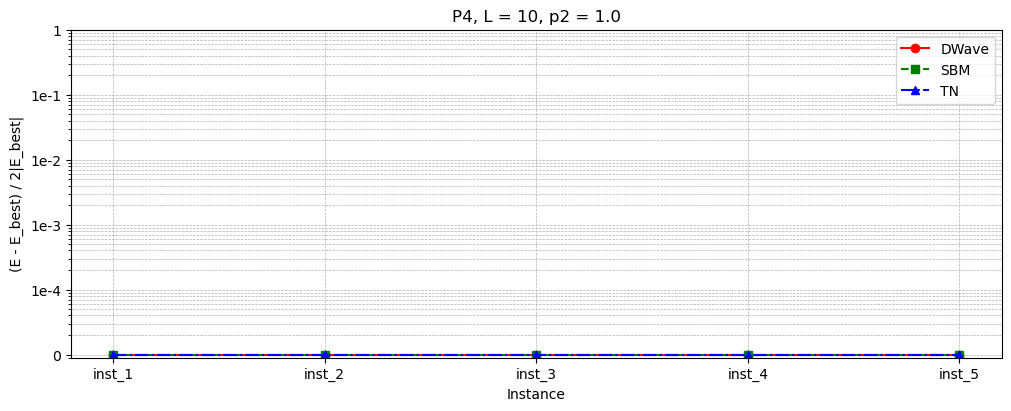

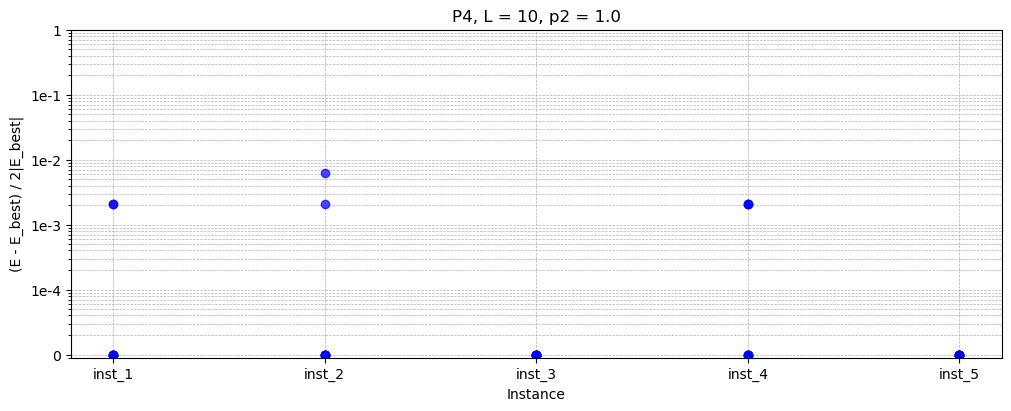

In [53]:
TOPOLOGY = "P4"
L = "10"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", "new", f"{TOPOLOGY}_L{L}_droplets")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, TOPOLOGY, L)


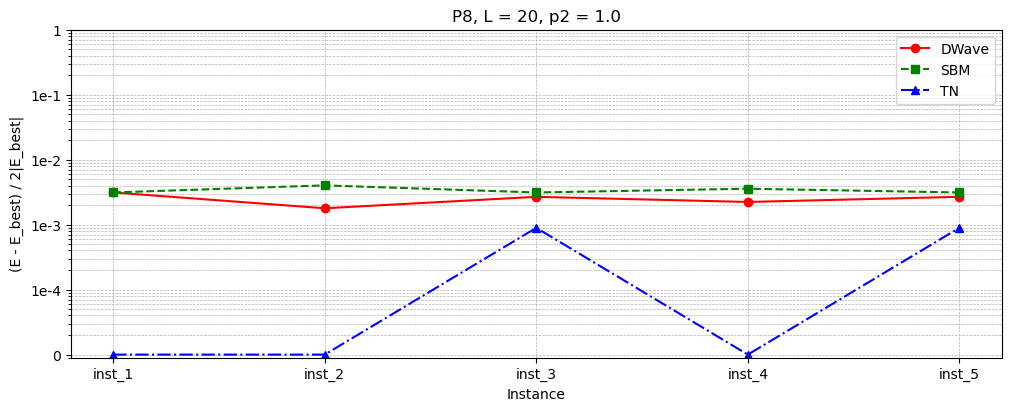

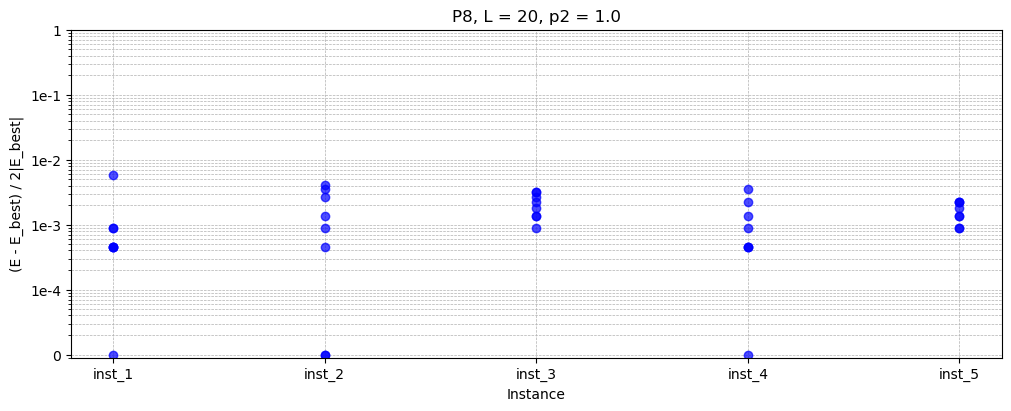

In [54]:
TOPOLOGY = "P8"
L = "20"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", "new", f"{TOPOLOGY}_L{L}_droplets")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, TOPOLOGY, L)


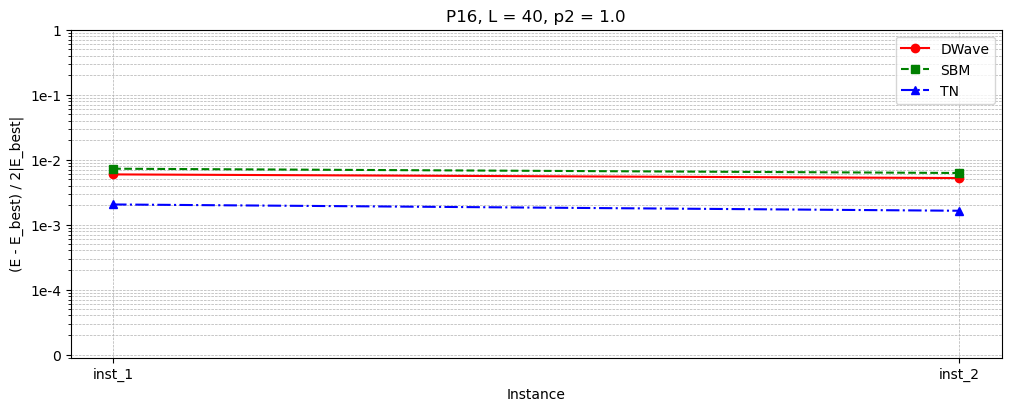

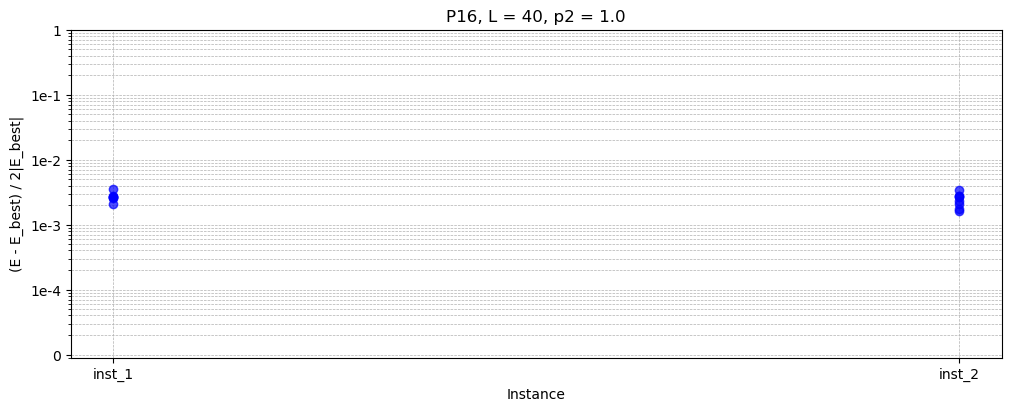

In [55]:
TOPOLOGY = "P16"
L = "40"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", "new", f"{TOPOLOGY}_L{L}_droplets")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, TOPOLOGY, L)


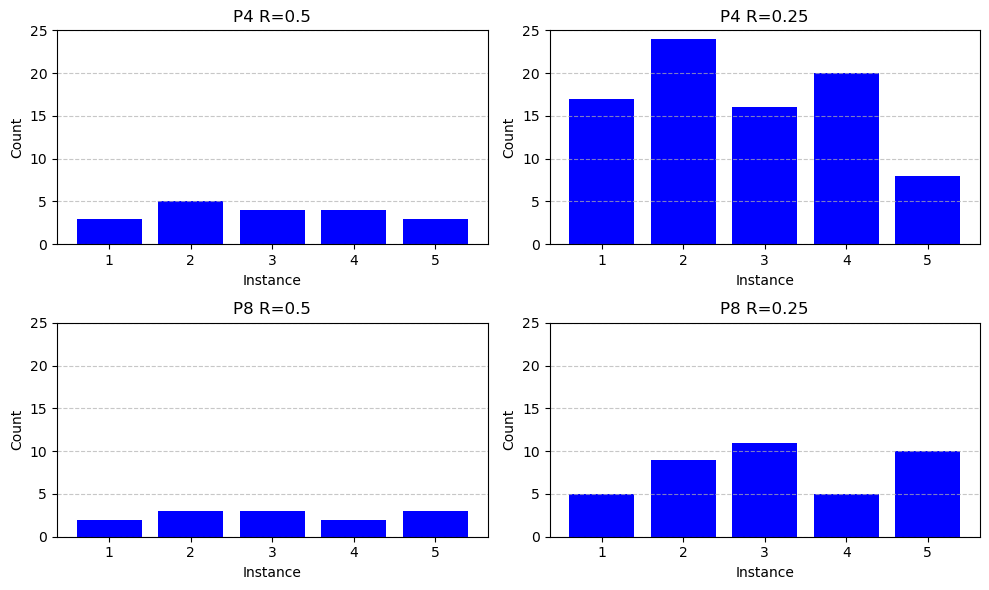

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import os

root = os.getcwd()
files = [
    os.path.join(root,"droplets/P4_adv6.4/results_solver_ar01_dr05/tile_planting_2D_L_10_p1_0.0_p2_1.0_p3_0.0_inst_1/union.csv"),
    os.path.join(root,"droplets/P4_adv6.4/results_solver_ar01_dr025/tile_planting_2D_L_10_p1_0.0_p2_1.0_p3_0.0_inst_1/union.csv"),
    os.path.join(root,"droplets/P8_adv6.4/results_solver_ar01_dr05/tile_planting_2D_L_20_p1_0.0_p2_1.0_p3_0.0_inst_1/union.csv"),
    os.path.join(root,"droplets/P8_adv6.4/results_solver_ar01_dr025/tile_planting_2D_L_20_p1_0.0_p2_1.0_p3_0.0_inst_1/union.csv"),
]

# Odpowiednie tytuły dla wykresów
titles = [
    "P4 R=0.5",
    "P4 R=0.25",
    "P8 R=0.5",
    "P8 R=0.25"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, file in enumerate(files):
    if os.path.exists(file):
        df = pd.read_csv(file)
        instances = [name.split("_inst_")[1].split("_")[0] for name in df["Name"]]
        counts = df["Count"]
        axes[i].set_ylim(0, 25)
        axes[i].bar(instances, counts, color="blue")
        axes[i].set_title(titles[i])  # Ustawienie tytułu wykresu
        axes[i].set_xlabel("Instance")
        axes[i].set_ylabel("Count")
        axes[i].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()